In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,average_precision_score

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ColabNotebooks/Santander_Competition/"

In [ ]:
df_train=pd.read_csv(f'{DATA_PATH}/train.csv')

In [ ]:
x=df_train.drop(['ID_code','target'],axis=1)
y=df_train['target']

**tuning parameters**

In [ ]:
# Small stratified sample for hyperparameter tuning
x_tune, _, y_tune, _ = train_test_split( x, y, train_size=0.10, random_state=42, stratify=y)

**XGBoost**

In [ ]:
negatives = (y_tune == 0).sum()
positives = (y_tune == 1).sum()

scale_pos_weight = negatives / positives
scale_pos_weight

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_depth': [5, 6, 8,10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.5, 1, 2],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}

In [ ]:
model_xgb=xgb.XGBClassifier(random_state=42, objective='binary:logistic',
                            tree_method='hist',
                            scale_pos_weight=scale_pos_weight,
                            eval_metric='auc',
                            n_jobs=1)

In [ ]:
random_cv_xgb = RandomizedSearchCV(estimator = model_xgb,
                               param_distributions = param_grid_xgb,
                               random_state = 42,
                               cv = cv_strategy,
                               n_iter = 25,
                               scoring = 'roc_auc',
                               verbose = 5,
                               return_train_score = True,
                               n_jobs=1 )
random_cv_xgb.fit(x_tune, y_tune)

random_cv_xgb.best_estimator_


random_cv_xgb.best_estimator_
print("Best ROC-AUC CV:", random_cv_xgb.best_score_)
print("Best parameters:")
print(random_cv_xgb.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV 1/3] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=1.0;, score=(train=1.000, test=0.820) total time=  43.5s
[CV 2/3] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=1.0;, score=(train=1.000, test=0.818) total time=  42.2s
[CV 3/3] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=1.0;, score=(train=1.000, test=0.829) total time=  43.4s
[CV 1/3] END colsample_bytree=1.0, gamma=1, learning_rate=0.01, max_depth=10, min_child_weight=10, n_estimators=500, reg_alpha=0.1, reg_lambda=10, subsample=1.0;, score=(train=1.000, test=0.811) total time= 2.1min
[CV 2/3] END colsample_bytree=1.0, gamma=1, learning_rate=0.01, max_depth=10, min_child_weight=10,

**running with best parameters**

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [ ]:
final_params = random_cv_xgb.best_params_

negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()

scale_pos_weight = negatives / positives

model_xgb_tuned=xgb.XGBClassifier(**final_params, random_state=42, objective='binary:logistic', tree_method='hist', scale_pos_weight=scale_pos_weight, eval_metric='auc', n_jobs=1)
model_xgb_tuned.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=7, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=1, num_parallel_tree=None, ...)

In [ ]:
y_pred=model_xgb_tuned.predict(x_test)
y_prob = model_xgb_tuned.predict_proba(x_test)[:,1]

print('accuracy: ' + str(accuracy_score(y_test,y_pred)))
print('confusion matrix: \n' + str(confusion_matrix(y_test,y_pred)))
print('classification report: \n' + str(classification_report(y_test,y_pred)))
print('roc_auc_score: ' + str(roc_auc_score(y_test,y_prob)))
print('pr_auc_score: ' + str(average_precision_score(y_test,y_prob)))


accuracy: 0.9035
confusion matrix: 
[[34080  1900]
 [ 1960  2060]]
classification report: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     35980
           1       0.52      0.51      0.52      4020

    accuracy                           0.90     40000
   macro avg       0.73      0.73      0.73     40000
weighted avg       0.90      0.90      0.90     40000

roc_auc_score: 0.8761945380103374
pr_auc_score: 0.5413709864558722


In [ ]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold: 0.2
[[24575 11405]
 [  494  3526]]
              precision    recall  f1-score   support

           0       0.98      0.68      0.81     35980
           1       0.24      0.88      0.37      4020

    accuracy                           0.70     40000
   macro avg       0.61      0.78      0.59     40000
weighted avg       0.91      0.70      0.76     40000


Threshold: 0.3
[[29703  6277]
 [  959  3061]]
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     35980
           1       0.33      0.76      0.46      4020

    accuracy                           0.82     40000
   macro avg       0.65      0.79      0.67     40000
weighted avg       0.90      0.82      0.85     40000


Threshold: 0.4
[[32450  3530]
 [ 1452  2568]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     35980
           1       0.42      0.64      0.51      4020

    accuracy                           0.

In [ ]:
xgb_results = pd.DataFrame({
    'y_true': y_test.values,
    'xgb_probability': y_prob,
    'xgb_prediction_05': y_pred
})

xgb_results.to_csv(f'{DATA_PATH}/outputs/xgb_validation_results.csv', index=False)

best_params = model_xgb_tuned.get_params()

joblib.dump(model_xgb_tuned, f'{DATA_PATH}/outputs/best_xgb_model.pkl')
joblib.dump(best_params, f'{DATA_PATH}/outputs/best_xgb_params.pkl')

np.save("outputs/y_test_xgb.npy", y_test)
np.save("outputs/xgb_y_prob_xgb.npy", y_prob)

['/content/drive/MyDrive/ColabNotebooks/Santander_Competition//best_xgb_params.pkl']

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

In [ ]:
feauturesImportances=pd.DataFrame(model_xgb_tuned.feature_importances_, x.columns, columns=['importance'])
feauturesImportances.sort_values('importance',ascending=False)

,importance
var_81,0.016419
var_139,0.013991
var_12,0.011399
var_110,0.011360
var_26,0.011114
...,...
var_38,0.002749
var_183,0.002727
var_69,0.002676
var_117,0.002653


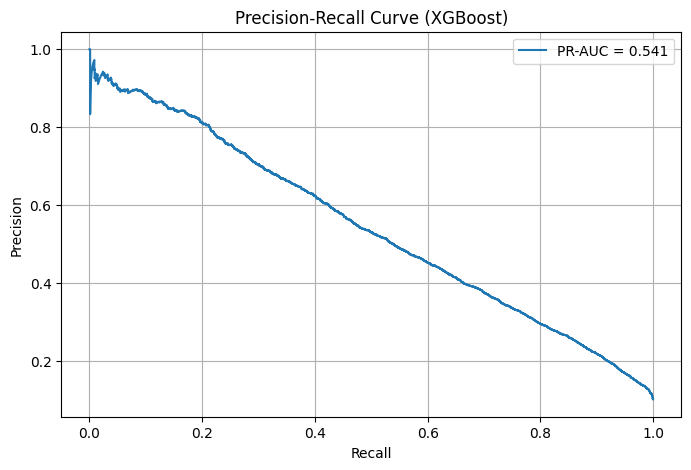

In [ ]:
xgb_resultssaved= pd.read_csv(f'{DATA_PATH}/outputs/xgb_validation_results.csv')

xgb_resultssaved
y_test=xgb_resultssaved['y_true']
y_prob=xgb_resultssaved['xgb_probability']
y_pred=xgb_resultssaved['xgb_prediction_05']

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
# PR-AUC / Average Precision
pr_auc = average_precision_score(y_test, y_prob)


plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.legend()
plt.grid(True)
plt.savefig(f'{DATA_PATH}/images/pr_curve_xgboost.png', dpi=300, bbox_inches="tight")
plt.show()

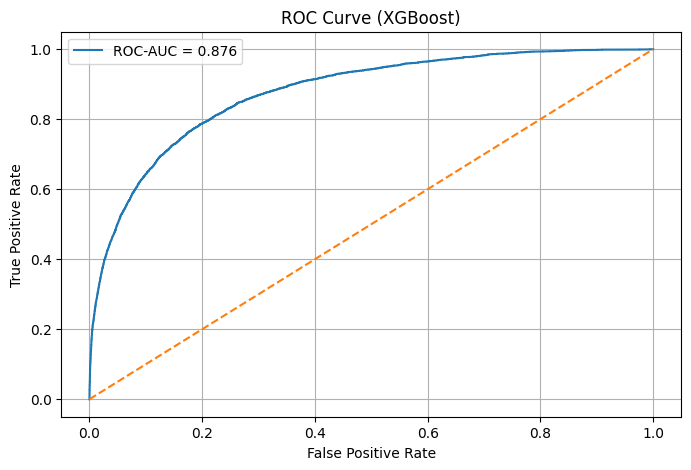

In [ ]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost)")
plt.legend()
plt.grid(True)
plt.savefig(f'{DATA_PATH}/images/roc_curve_xgboost.png', dpi=300, bbox_inches="tight")
plt.show()

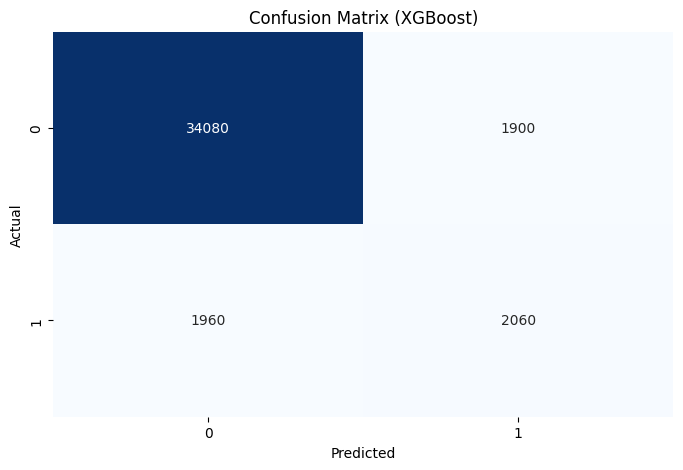

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.savefig(f'{DATA_PATH}/images/confusion_matrix_xgboost.png', dpi=300, bbox_inches="tight")
plt.show()